#📌 Extracción

In [1]:
import requests
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"

response = requests.get(url)
data = response.json()

In [3]:
df = pd.DataFrame(data)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [4]:
df = pd.json_normalize(data)
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


#🔧 Transformación

In [5]:
#Buscamos valores nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [6]:
df.dtypes

customerID                    object
Churn                         object
customer.gender               object
customer.SeniorCitizen         int64
customer.Partner              object
customer.Dependents           object
customer.tenure                int64
phone.PhoneService            object
phone.MultipleLines           object
internet.InternetService      object
internet.OnlineSecurity       object
internet.OnlineBackup         object
internet.DeviceProtection     object
internet.TechSupport          object
internet.StreamingTV          object
internet.StreamingMovies      object
account.Contract              object
account.PaperlessBilling      object
account.PaymentMethod         object
account.Charges.Monthly      float64
account.Charges.Total         object
dtype: object

In [7]:
#Comprobamos incoherencias
print("Numero de Nulos \n", df.isnull().sum())

Numero de Nulos 
 customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64


In [8]:
#valores en blanco
df.apply(lambda x: x.astype(str).str.strip() == '').sum()

customerID                     0
Churn                        224
customer.gender                0
customer.SeniorCitizen         0
customer.Partner               0
customer.Dependents            0
customer.tenure                0
phone.PhoneService             0
phone.MultipleLines            0
internet.InternetService       0
internet.OnlineSecurity        0
internet.OnlineBackup          0
internet.DeviceProtection      0
internet.TechSupport           0
internet.StreamingTV           0
internet.StreamingMovies       0
account.Contract               0
account.PaperlessBilling       0
account.PaymentMethod          0
account.Charges.Monthly        0
account.Charges.Total         11
dtype: int64

In [9]:
#Ubicación de los valores en blanco dentro del Churn
df[df['Churn'] == ""]

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
30,0047-ZHDTW,,Female,0,No,No,11,Yes,Yes,Fiber optic,...,No,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),79.00,929.3
75,0120-YZLQA,,Male,0,No,No,71,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),19.90,1355.1
96,0154-QYHJU,,Male,0,No,No,29,Yes,No,DSL,...,Yes,No,Yes,No,No,One year,Yes,Electronic check,58.75,1696.2
98,0162-RZGMZ,,Female,1,No,No,5,Yes,No,DSL,...,Yes,No,Yes,No,No,Month-to-month,No,Credit card (automatic),59.90,287.85
175,0274-VVQOQ,,Male,1,Yes,No,65,Yes,Yes,Fiber optic,...,Yes,Yes,No,Yes,Yes,One year,Yes,Bank transfer (automatic),103.15,6792.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7158,9840-GSRFX,,Female,0,No,No,14,Yes,Yes,DSL,...,Yes,No,No,No,No,One year,Yes,Mailed check,54.25,773.2
7180,9872-RZQQB,,Female,0,Yes,No,49,No,No phone service,DSL,...,No,No,No,Yes,No,Month-to-month,No,Bank transfer (automatic),40.65,2070.75
7211,9920-GNDMB,,Male,0,No,No,9,Yes,Yes,Fiber optic,...,No,No,No,No,No,Month-to-month,Yes,Electronic check,76.25,684.85
7239,9955-RVWSC,,Female,0,Yes,Yes,67,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),19.25,1372.9


In [10]:
faltantes = df.loc[
    ~df['account.Charges.Total']
        .astype(str)
        .str.replace('.', '', 1)
        .str.isnumeric()
]

faltantes

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
975,1371-DWPAZ,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,
1775,2520-SGTTA,No,Female,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,
1955,2775-SEFEE,No,Male,0,No,Yes,0,Yes,Yes,DSL,...,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,
2075,2923-ARZLG,No,Male,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,
2232,3115-CZMZD,No,Male,0,No,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,
2308,3213-VVOLG,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,
2930,4075-WKNIU,No,Female,0,Yes,Yes,0,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,
3134,4367-NUYAO,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,
3203,4472-LVYGI,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,
4169,5709-LVOEQ,No,Female,0,Yes,Yes,0,Yes,No,DSL,...,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,


In [11]:
#Valores duplicados
print("Numero de duplicados", df.duplicated().sum())

Numero de duplicados 0


In [12]:
#Valores únicos
for col in df.columns:
  print(f'{col}: {df[col].nunique()}')

customerID: 7267
Churn: 3
customer.gender: 2
customer.SeniorCitizen: 2
customer.Partner: 2
customer.Dependents: 2
customer.tenure: 73
phone.PhoneService: 2
phone.MultipleLines: 3
internet.InternetService: 3
internet.OnlineSecurity: 3
internet.OnlineBackup: 3
internet.DeviceProtection: 3
internet.TechSupport: 3
internet.StreamingTV: 3
internet.StreamingMovies: 3
account.Contract: 3
account.PaperlessBilling: 2
account.PaymentMethod: 4
account.Charges.Monthly: 1585
account.Charges.Total: 6531


In [13]:
#buscamos valores en blanco en la columna Churn.

for col in df.columns:
  print(f" Valores unicos en la columna'{col}: {df[col].nunique()}'")

  if df[col].nunique() < 50:
    print(df[col].unique())
    print('-' * 50)
     

 Valores unicos en la columna'customerID: 7267'
 Valores unicos en la columna'Churn: 3'
['No' 'Yes' '']
--------------------------------------------------
 Valores unicos en la columna'customer.gender: 2'
['Female' 'Male']
--------------------------------------------------
 Valores unicos en la columna'customer.SeniorCitizen: 2'
[0 1]
--------------------------------------------------
 Valores unicos en la columna'customer.Partner: 2'
['Yes' 'No']
--------------------------------------------------
 Valores unicos en la columna'customer.Dependents: 2'
['Yes' 'No']
--------------------------------------------------
 Valores unicos en la columna'customer.tenure: 73'
 Valores unicos en la columna'phone.PhoneService: 2'
['Yes' 'No']
--------------------------------------------------
 Valores unicos en la columna'phone.MultipleLines: 3'
['No' 'Yes' 'No phone service']
--------------------------------------------------
 Valores unicos en la columna'internet.InternetService: 3'
['DSL' 'Fiber o

In [14]:
df['cuentas_diarias'] = df['account.Charges.Monthly'] / 30
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,cuentas_diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,55.15,742.9,1.838333
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7,2.836667
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.261667


In [15]:
#Transformación de datos
columnas = {
    'customerID': 'id',
    'customer.gender': 'genero',
    'customer.SeniorCitizen': 'tiene +60',
    'customer.Partner': 'posee_pareja',
    'customer.Dependents': 'posee_dependientes',
    'customer.tenure': 'tiempo_contrato',
    'phone.PhoneService': 'servicio_telefono',
    'phone.MultipleLines': 'multiples_lineas',
    'internet.InternetService': 'tipo_internet',
    'internet.OnlineSecurity': 'seguridad_online',
    'internet.OnlineBackup': 'backup_online',
    'internet.DeviceProtection': 'proteccion_dispositivo',
    'internet.TechSupport': 'soporte_tecnico',
    'internet.StreamingTV': 'streaming_tv',
    'internet.StreamingMovies': 'streaming_peliculas',
    'account.Contract': 'tipo_contrato',
    'account.PaperlessBilling': 'factura_digital',
    'account.PaymentMethod': 'metodo_pago',
    'account.Charges.Monthly': 'valor_mensual',
    'account.Charges.Total': 'total_cobrado'
}
df = df.rename(columns= columnas)
df.head()

,id,Churn,genero,tiene +60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensual,total_cobrado,cuentas_diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4,2.796667


In [16]:
df['genero'] = df['genero'].replace({'Female': 'Femenino', 'Male': 'Masculino'})
df['multiples_lineas'] = df['multiples_lineas'].replace({'No phone service': 'Sin servicio de teléfono'})
df['tipo_internet'] = df['tipo_internet'].replace({'No': '0', 'Fiber optic': 'Fibra óptica'})
df['seguridad_online'] = df['seguridad_online'].replace({'No internet service': 'Sin servicio de internet'})
df['backup_online'] = df['backup_online'].replace({'No internet service': 'Sin servicio de internet'})
df['proteccion_dispositivo'] = df['proteccion_dispositivo'].replace({'No internet service': 'Sin servicio de internet'})
df['soporte_tecnico'] = df['soporte_tecnico'].replace({'No internet service': 'Sin servicio de internet'})
df['streaming_tv'] = df['streaming_tv'].replace({'No internet service': 'Sin servicio de internet'})
df['streaming_peliculas'] = df['streaming_peliculas'].replace({'No internet service': 'Sin servicio de internet'})
df['tipo_contrato'] = df['tipo_contrato'].replace({'One year': 'Anual', 'Month-to-month': 'Mensual', 'Two year': 'Bienal'})
df.head()

,id,Churn,genero,tiene +60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensual,total_cobrado,cuentas_diarias
0,0002-ORFBO,No,Femenino,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,Anual,Yes,Mailed check,65.6,593.3,2.186667
1,0003-MKNFE,No,Masculino,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Mensual,No,Mailed check,59.9,542.4,1.996667
2,0004-TLHLJ,Yes,Masculino,0,No,No,4,Yes,No,Fibra óptica,...,Yes,No,No,No,Mensual,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Masculino,1,Yes,No,13,Yes,No,Fibra óptica,...,Yes,No,Yes,Yes,Mensual,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Femenino,1,Yes,No,3,Yes,No,Fibra óptica,...,No,Yes,Yes,No,Mensual,Yes,Mailed check,83.9,267.4,2.796667


In [17]:
df['metodo_pago'] = df['metodo_pago'].replace({
    'Mailed check': 'Cheque enviado por correo',
    'Electronic check': 'Cheque electrónico',
    'Credit card (automatic)': 'Tarjeta de crédito (automático)',
    'Bank transfer (automatic)': 'Transferencia bancaria (automática)'
})
df.head()

,id,Churn,genero,tiene +60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensual,total_cobrado,cuentas_diarias
0,0002-ORFBO,No,Femenino,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,Anual,Yes,Cheque enviado por correo,65.6,593.3,2.186667
1,0003-MKNFE,No,Masculino,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Mensual,No,Cheque enviado por correo,59.9,542.4,1.996667
2,0004-TLHLJ,Yes,Masculino,0,No,No,4,Yes,No,Fibra óptica,...,Yes,No,No,No,Mensual,Yes,Cheque electrónico,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Masculino,1,Yes,No,13,Yes,No,Fibra óptica,...,Yes,No,Yes,Yes,Mensual,Yes,Cheque electrónico,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Femenino,1,Yes,No,3,Yes,No,Fibra óptica,...,No,Yes,Yes,No,Mensual,Yes,Cheque enviado por correo,83.9,267.4,2.796667


In [18]:
binarios = [
    'Churn',
    'posee_pareja',
    'posee_dependientes',
    'servicio_telefono',
    'multiples_lineas',
    'seguridad_online',
    'backup_online',
    'proteccion_dispositivo',
    'soporte_tecnico',
    'streaming_tv',
    'streaming_peliculas',
    'factura_digital'
]

for col in binarios:
    df[col] = df[col].map({
        'Yes': 1,
        'No': 0
        })
df.head()

,id,Churn,genero,tiene +60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensual,total_cobrado,cuentas_diarias
0,0002-ORFBO,0.0,Femenino,0,1,1,9,1,0.0,DSL,...,0.0,1.0,1.0,0.0,Anual,1,Cheque enviado por correo,65.6,593.3,2.186667
1,0003-MKNFE,0.0,Masculino,0,0,0,9,1,1.0,DSL,...,0.0,0.0,0.0,1.0,Mensual,0,Cheque enviado por correo,59.9,542.4,1.996667
2,0004-TLHLJ,1.0,Masculino,0,0,0,4,1,0.0,Fibra óptica,...,1.0,0.0,0.0,0.0,Mensual,1,Cheque electrónico,73.9,280.85,2.463333
3,0011-IGKFF,1.0,Masculino,1,1,0,13,1,0.0,Fibra óptica,...,1.0,0.0,1.0,1.0,Mensual,1,Cheque electrónico,98.0,1237.85,3.266667
4,0013-EXCHZ,1.0,Femenino,1,1,0,3,1,0.0,Fibra óptica,...,0.0,1.0,1.0,0.0,Mensual,1,Cheque enviado por correo,83.9,267.4,2.796667


#📊 Carga y análisis

In [19]:
df['total_cobrado'] = pd.to_numeric(
    df['total_cobrado'].astype(str).str.replace(r"[^\d.-]", "", regex=True),
    errors="coerce"
)

In [20]:
describe = df.describe()

formatted = describe.astype(object)

binarias = [
    'Churn', 'tiene +60', 'posee_pareja', 'posee_dependientes',
    'servicio_telefono', 'multiples_lineas', 'tipo_internet', 'seguridad_online',
    'backup_online', 'proteccion_dispositivo', 'soporte_tecnico',
    'streaming_tv', 'streaming_peliculas', 'factura_digital'
]

for col in binarias:
    if col in describe.columns:
        for idx in formatted.index:
            if idx == 'count':
                formatted.loc[idx, col] = f"{int(describe.loc[idx, col])}"
            else:
                formatted.loc[idx, col] = f"{describe.loc[idx, col]*100:.1f}%"

monetarias = ['valor_mensual', 'total_cobrado', 'cuentas_diarias']
for col in monetarias:
    if col in describe.columns:
        for idx in formatted.index:
            if idx == 'count':
                formatted.loc[idx, col] = f"{int(describe.loc[idx, col])}"
            else:
                formatted.loc[idx, col] = f"${describe.loc[idx, col]:,.1f}"

contrato = 'tiempo_contrato'
if contrato in describe.columns:
    for idx in formatted.index:
        if idx == 'count':
            formatted.loc[idx, contrato] = f"{int(describe.loc[idx, contrato])}"
        else:
            formatted.loc[idx, contrato] = f"{describe.loc[idx, contrato]:.1f}"

display(formatted)

print("\nNotas interpretativas:")
print(f"Churn: {describe.loc['mean','Churn']*100:.1f}% de clientes cancelaron.")
print(f"Tiene +60: {describe.loc['mean','tiene +60']*100:.1f}% son adultos mayores.")
print(f"Posee pareja: {describe.loc['mean','posee_pareja']*100:.1f}% tienen pareja.")
print(f"Posee dependientes: {describe.loc['mean','posee_dependientes']*100:.1f}% tienen dependientes.")
print(f"Tiempo de contrato: mediana = {describe.loc['50%','tiempo_contrato']:.1f} meses, máximo = {describe.loc['max','tiempo_contrato']:.1f} meses.")
print(f"Valor mensual: media = ${describe.loc['mean','valor_mensual']:.1f}, mediana = ${describe.loc['50%','valor_mensual']:.1f}.")
print(f"Total cobrado: media = ${describe.loc['mean','total_cobrado']:.1f}, mediana = ${describe.loc['50%','total_cobrado']:.1f}, máximo = ${describe.loc['max','total_cobrado']:.1f}.")
print(f"Cuentas diarias: media = ${describe.loc['mean','cuentas_diarias']:.1f}, mediana = ${describe.loc['50%','cuentas_diarias']:.1f}.")

,Churn,tiene +60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,seguridad_online,backup_online,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,factura_digital,valor_mensual,total_cobrado,cuentas_diarias
count,7043,7267,7267,7267,7267,7267,6560,5686,5686,5686,5686,5686,5686,7267,7267,7256,7267
mean,26.5%,16.3%,48.4%,30.0%,32.3,90.3%,46.7%,36.5%,44.0%,43.8%,37.0%,49.1%,49.5%,59.3%,$64.7,"$2,280.6",$2.2
std,44.2%,36.9%,50.0%,45.8%,24.6,29.6%,49.9%,48.2%,49.6%,49.6%,48.3%,50.0%,50.0%,49.1%,$30.1,"$2,268.6",$1.0
min,0.0%,0.0%,0.0%,0.0%,0.0,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,$18.2,$18.8,$0.6
25%,0.0%,0.0%,0.0%,0.0%,9.0,100.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,$35.4,$400.2,$1.2
50%,0.0%,0.0%,0.0%,0.0%,29.0,100.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,100.0%,$70.3,"$1,391.0",$2.3
75%,100.0%,0.0%,100.0%,100.0%,55.0,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,$89.9,"$3,785.3",$3.0
max,100.0%,100.0%,100.0%,100.0%,72.0,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,$118.8,"$8,684.8",$4.0



Notas interpretativas:
Churn: 26.5% de clientes cancelaron.
Tiene +60: 16.3% son adultos mayores.
Posee pareja: 48.4% tienen pareja.
Posee dependientes: 30.0% tienen dependientes.
Tiempo de contrato: mediana = 29.0 meses, máximo = 72.0 meses.
Valor mensual: media = $64.7, mediana = $70.3.
Total cobrado: media = $2280.6, mediana = $1391.0, máximo = $8684.8.
Cuentas diarias: media = $2.2, mediana = $2.3.


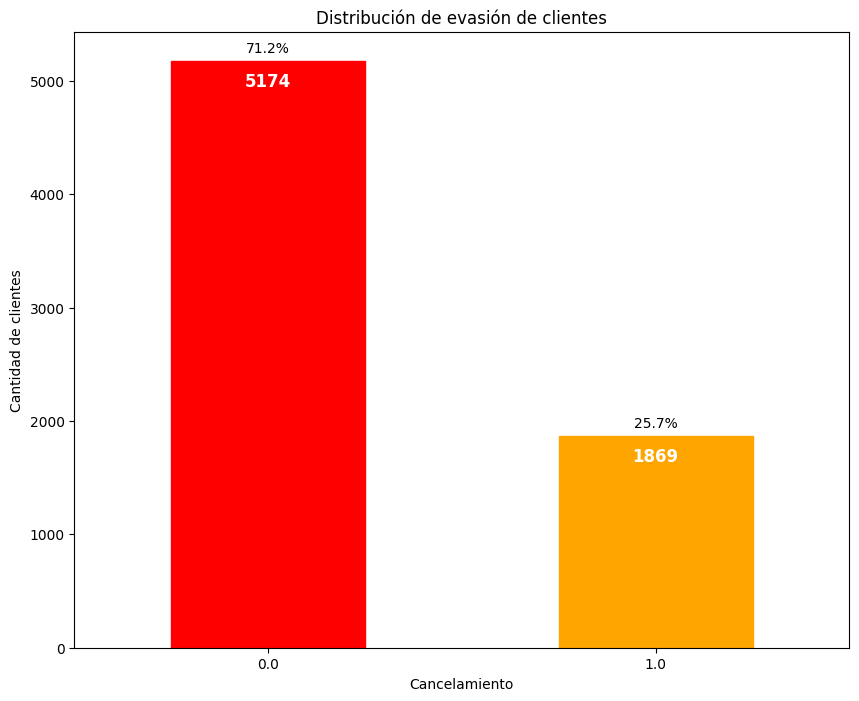

In [21]:
plt.figure(figsize=(10, 8))

churn_counts = df['Churn'].value_counts()
churn_percentages = (churn_counts / len(df)) * 100

ax = churn_counts.plot(kind='bar')

colores = ['red', 'orange']  #0 , 1.
for barra, color in zip(ax.patches, colores):
    barra.set_color(color)

plt.title('Distribución de evasión de clientes')
plt.xlabel('Cancelamiento')
plt.ylabel('Cantidad de clientes')
plt.xticks(rotation=0)

for i, percentage in enumerate(churn_percentages):
    ax.text(
        i,
        churn_counts.iloc[i] + 50,
        f'{percentage:.1f}%',
        ha='center',
        va='bottom'
    )
    ax.text(
        i,
        churn_counts.iloc[i] - 100,
        str(churn_counts.iloc[i]),
        ha='center',
        va='top',
        color='white',
        fontsize=12,
        fontweight='bold'
    )

plt.show()
    

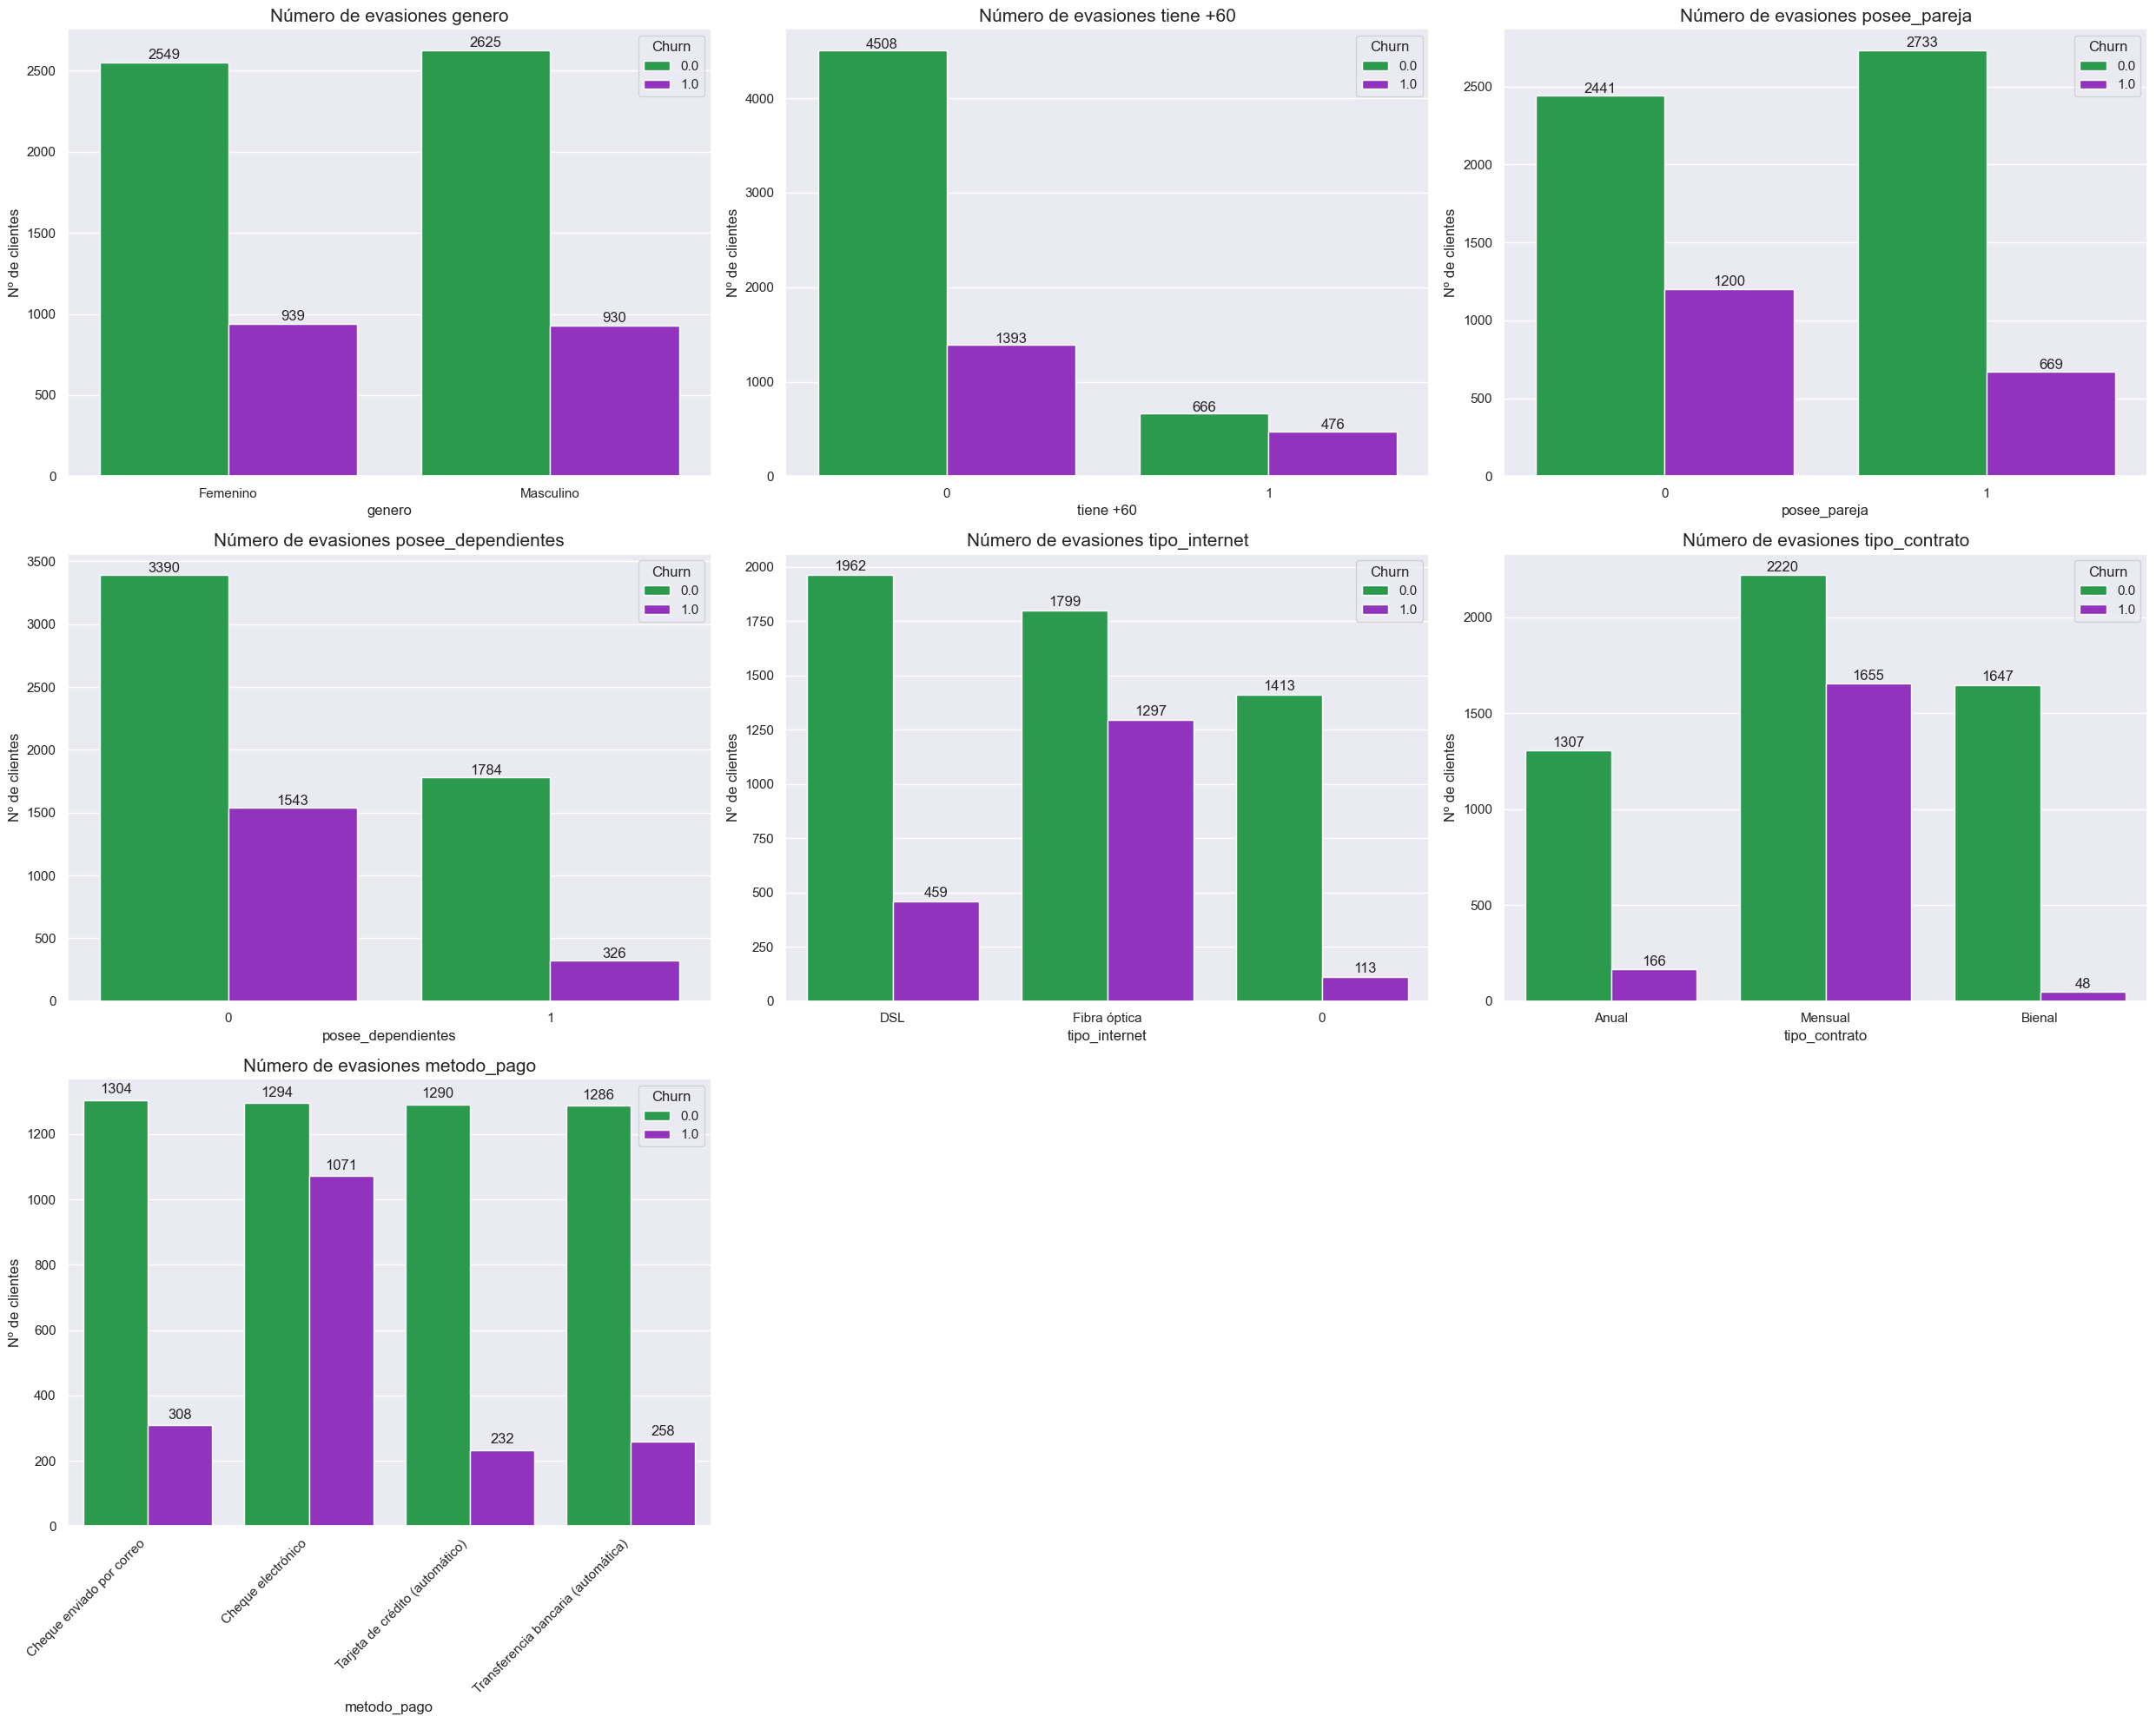

In [22]:
variables_categoricas = ['genero', 'tiene +60', 'posee_pareja',
                        'posee_dependientes', 'tipo_internet',
                         'tipo_contrato', 'metodo_pago',]

lista_variables_categoricas = list(enumerate(variables_categoricas))

sns.set(rc = {'figure.figsize':(25,20)})

for i in lista_variables_categoricas:

    plt.subplot(3, 3,  i[0]+1)
    ax = sns.countplot(data = df,
                    x = i[1],
                    hue = 'Churn',
                    palette = {0: "#19AC45", 1: "#991CD3"},
                    )

    ax.set_title(f'Número de evasiones {i[1]}', fontsize = 15)
    ax.set_ylabel('Nº de clientes', fontsize = 12)
    ax.set_xlabel(i[1], fontsize = 12)

    if i[1] == 'metodo_pago':
        plt.xticks(rotation=45, ha='right')

    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.text(p.get_x()+p.get_width()/2.,
            height + 20,
            '{:1.0f}'.format(height),
            ha='center',
            size = 12)

plt.tight_layout()
plt.show()

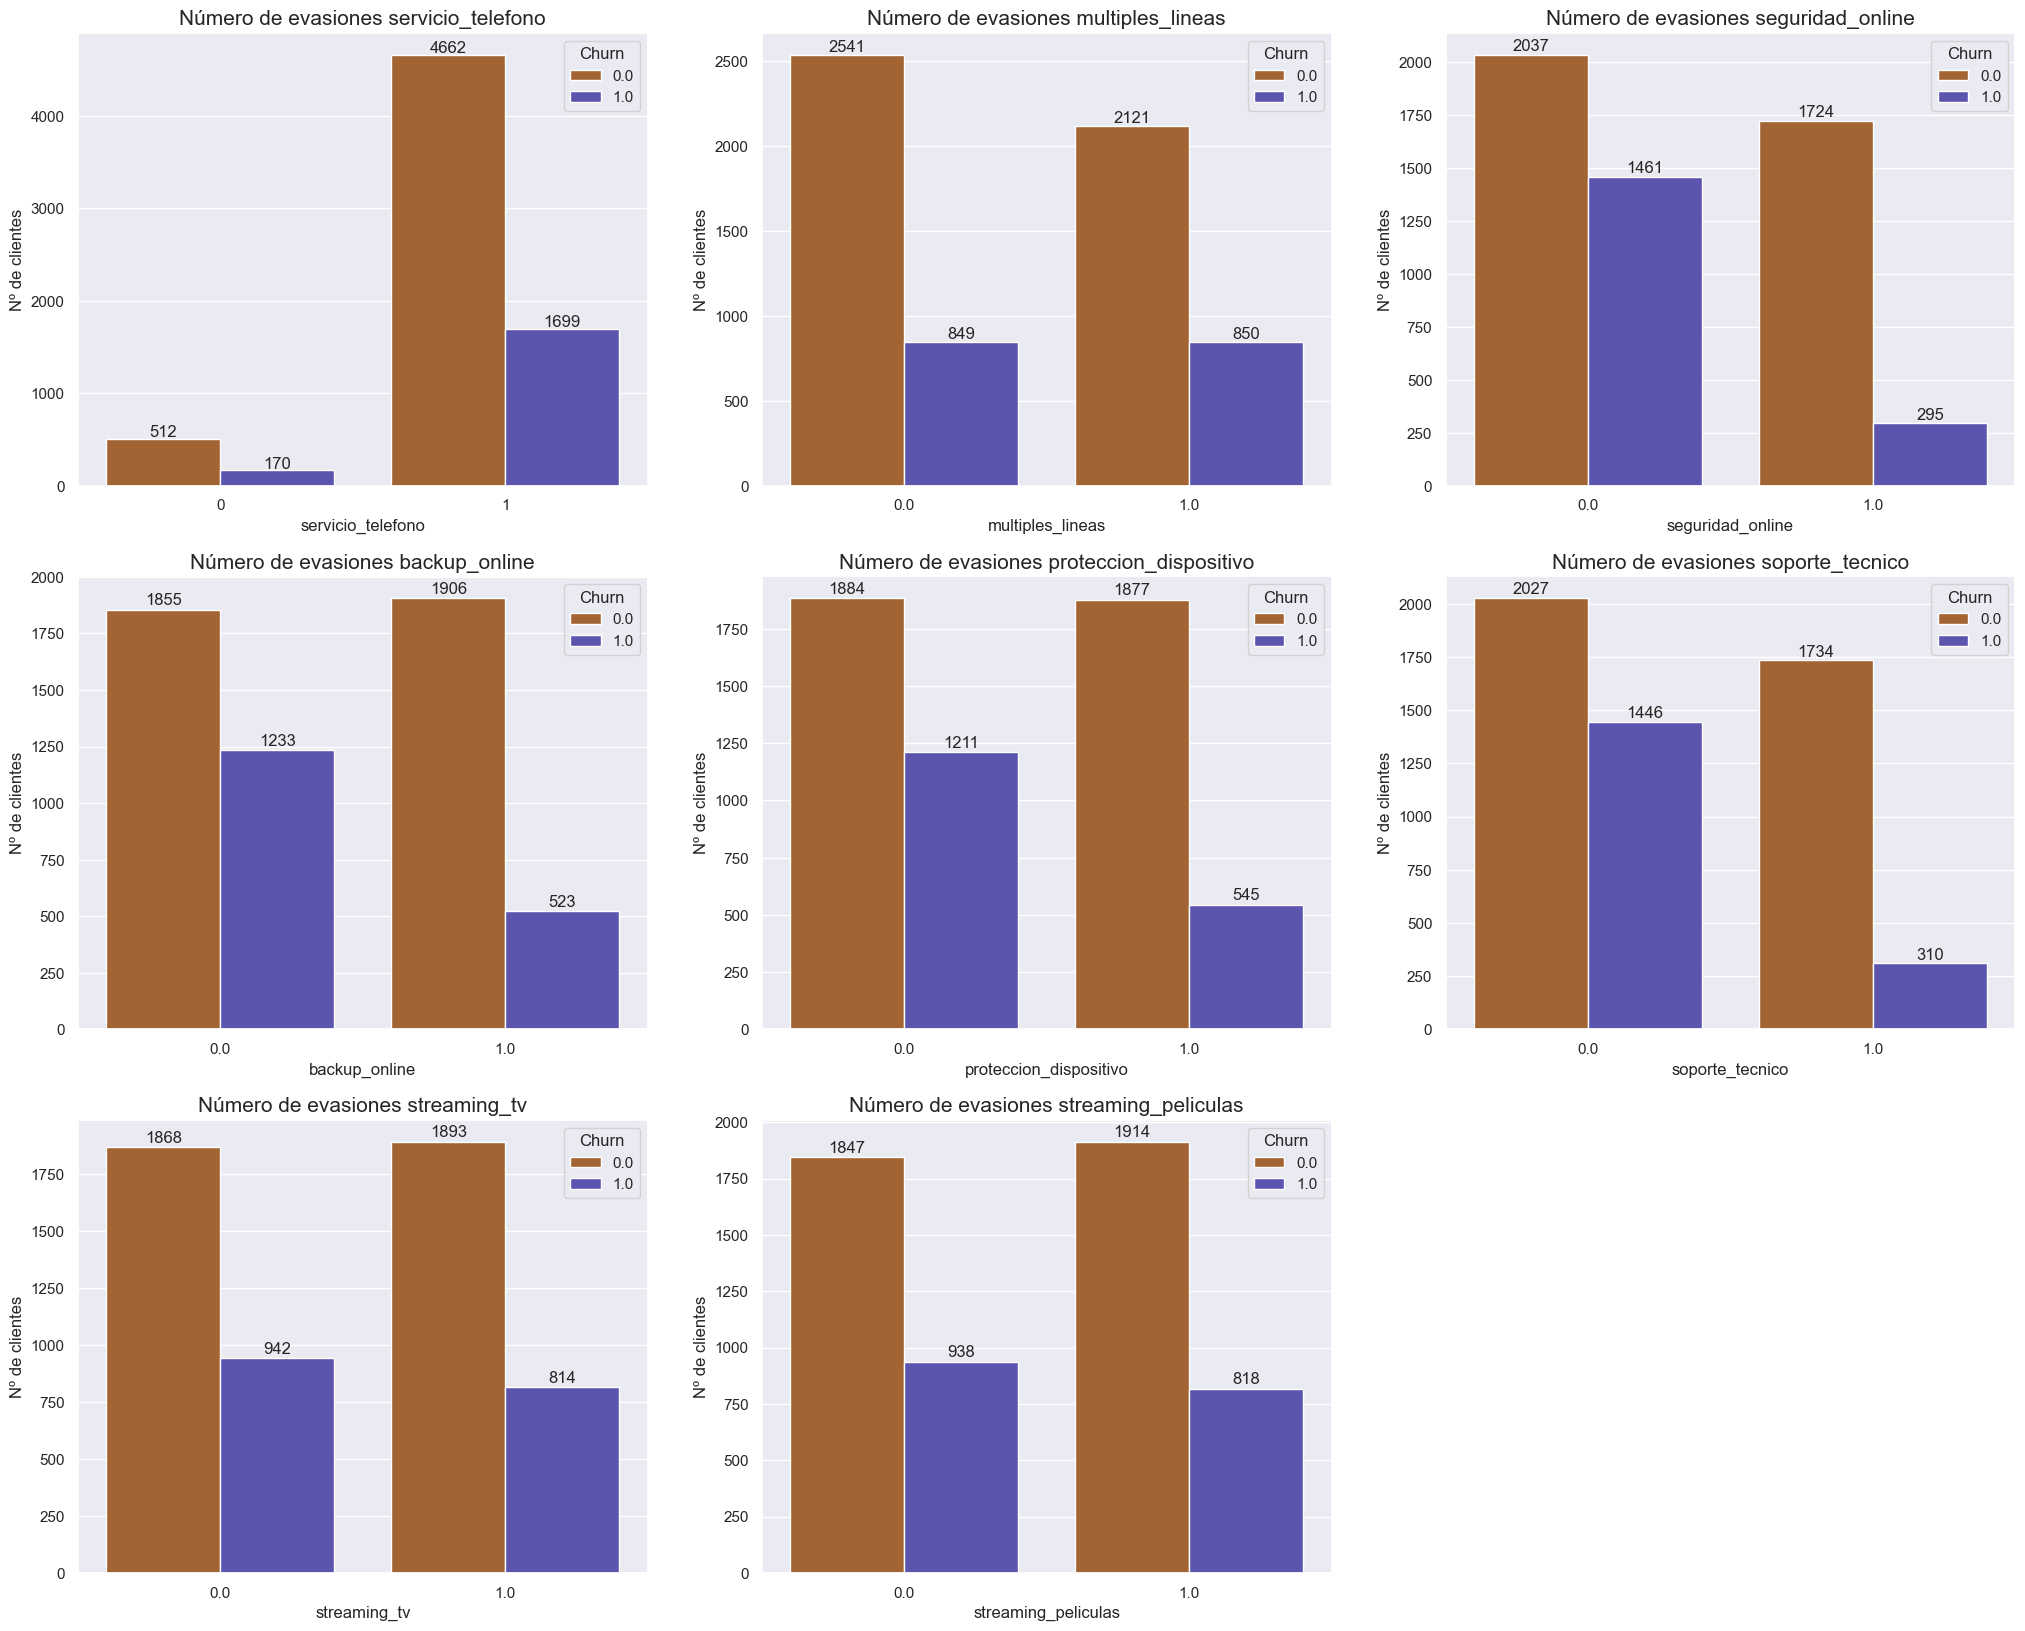

In [23]:
variables_categoricas = ['servicio_telefono', 'multiples_lineas', 'seguridad_online',
                        'backup_online', 'proteccion_dispositivo',
                         'soporte_tecnico', 'streaming_tv', 'streaming_peliculas',]

lista_variables_categoricas = list(enumerate(variables_categoricas))

sns.set(rc = {'figure.figsize':(25,20)})

for i in lista_variables_categoricas:

    plt.subplot(3, 3,  i[0]+1)
    ax = sns.countplot(data = df,
                    x = i[1],
                    hue = 'Churn',
                    palette = {0: "#b4621f", 1: "#4f47bb"},
                    )

    ax.set_title(f'Número de evasiones {i[1]}', fontsize = 15)
    ax.set_ylabel('Nº de clientes', fontsize = 12)
    ax.set_xlabel(i[1], fontsize = 12)

    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.text(p.get_x()+p.get_width()/2.,
            height + 20,
            '{:1.0f}'.format(height),
            ha='center',
            size = 12)

plt.show()

In [24]:
#Conteo de evasión por variables numéricas
df_grouped = df.groupby(['tiempo_contrato', 'Churn']).size().unstack(fill_value=0)

df_grouped['churn_rate'] = (df_grouped.get(1, 0) / df_grouped.sum(axis=1)) * 100

print(df_grouped['churn_rate'].map(lambda x: f'{x:.1f}%').to_string())

tiempo_contrato
0      0.0%
1     62.0%
2     51.7%
3     47.0%
4     47.2%
5     48.1%
6     36.4%
7     38.9%
8     34.1%
9     38.7%
10    38.8%
11    31.3%
12    32.5%
13    34.9%
14    31.6%
15    37.4%
16    35.0%
17    29.9%
18    24.7%
19    26.0%
20    25.4%
21    27.0%
22    30.0%
23    15.3%
24    24.5%
25    29.1%
26    19.0%
27    18.1%
28    21.1%
29    20.8%
30    22.2%
31    24.6%
32    27.5%
33    21.9%
34    18.5%
35    17.0%
36    20.0%
37    23.1%
38    22.0%
39    25.0%
40    20.3%
41    20.0%
42    21.5%
43    23.1%
44    11.8%
45     9.8%
46    16.2%
47    20.6%
48    14.1%
49    22.7%
50    14.7%
51    11.8%
52    10.0%
53    20.0%
54    19.1%
55    14.1%
56    12.5%
57    12.3%
58    16.4%
59    13.3%
60     7.9%
61    10.5%
62     7.1%
63     5.6%
64     5.0%
65    11.8%
66    14.6%
67    10.2%
68     9.0%
69     8.4%
70     9.2%
71     3.5%
72     1.7%


In [ ]:
fig = px.line(df_grouped.reset_index(),
              x='tiempo_contrato',
              y='churn_rate',
              markers=True,
              title='Tasa de Churn (%) por tiempo_contrato',
              color_discrete_sequence=['purple']
             )

fig.update_layout(title_x=0.5)
fig.update_traces(hovertemplate='tiempo_contrato=%{x}tasa de Churn=%{y:.1f}%')
fig.update_xaxes(title_text='tiempo_contrato (meses)')
fig.show()

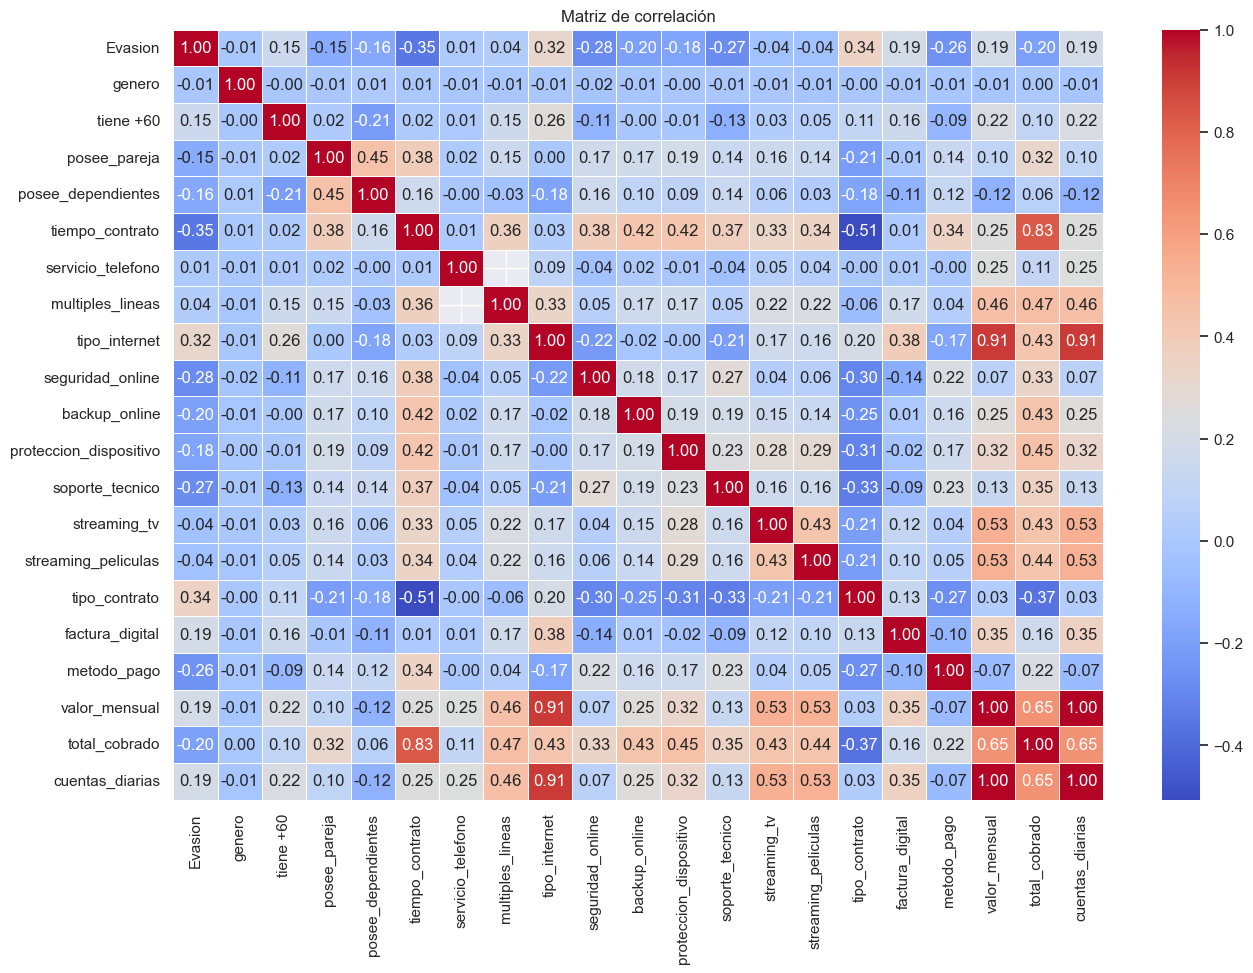

Evasion                   1.00
tipo_contrato             0.34
tipo_internet             0.32
valor_mensual             0.19
cuentas_diarias           0.19
factura_digital           0.19
tiene +60                 0.15
multiples_lineas          0.04
servicio_telefono         0.01
genero                   -0.01
streaming_tv             -0.04
streaming_peliculas      -0.04
posee_pareja             -0.15
posee_dependientes       -0.16
proteccion_dispositivo   -0.18
backup_online            -0.20
total_cobrado            -0.20
metodo_pago              -0.26
soporte_tecnico          -0.27
seguridad_online         -0.28
tiempo_contrato          -0.35


In [ ]:
#Seleccionamos las columnas que queremos correlacionar.
#Incluimos las numéricas originales y convertimos las categóricas relevantes.
df_corr = df.copy()

#Convertimos 'Sí'/'No' a 1/0 y otras categorías a números.
#Esto es necesario porque la correlación no puede calcularse sobre texto.
for col in df_corr.select_dtypes(include=['object']).columns:
    if col != 'id': #Ignoramos el ID del cliente
        df_corr[col] = df_corr[col].astype('category').cat.codes

#Cambiamos el nombre 'Churn' a 'Evasion' para mantener la coherencia.
df_corr = df_corr.rename(columns={'Churn': 'Evasion'})

#Calculamos la matriz de correlación.
correlation_matrix = df_corr.drop(columns=['id']).corr()

#Visualizamos con un mapa de Calor (Heatmap).
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de correlación')
plt.show()

#Imprimir todas las correlaciones con evasion.
print(correlation_matrix['Evasion'].sort_values(ascending=False).round(2).to_string())

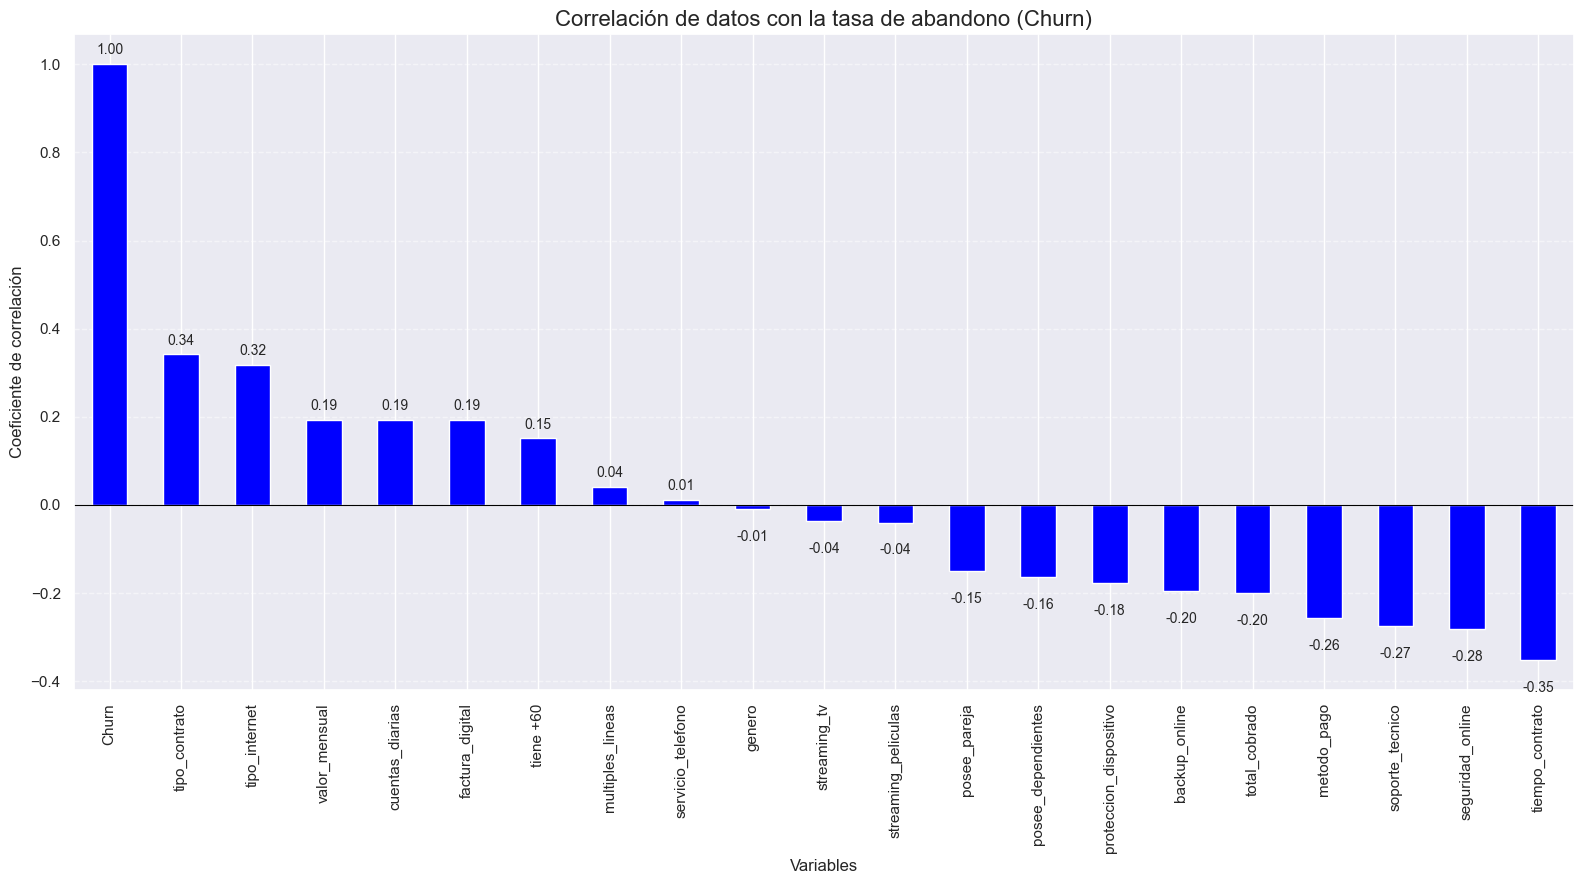

In [ ]:
#Preparación de los datos
df_corr_processed = df.copy()
for col in df_corr_processed.select_dtypes(include=['object']).columns:
    if col != 'id':
        df_corr_processed[col] = df_corr_processed[col].astype('category').cat.codes

df_corr_processed = df_corr_processed.drop(columns=['id'])

#Creación del gráfico
plt.figure(figsize=(16, 9))
correlaciones = df_corr_processed.corr()['Churn'].sort_values(ascending=False)
ax = correlaciones.plot(kind='bar', color='blue')

#Añadir los valores dinámicamente
for p in ax.patches:
    height = p.get_height()
    #Si el valor es positivo, lo pone arriba. Si es negativo, lo pone abajo.
    va_position = 'bottom' if height > 0 else 'top'
    offset = 5 if height > 0 else -15 #Desplazamiento en puntos

    ax.annotate(f'{height:.2f}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center',
                va=va_position,
                xytext=(0, offset),
                textcoords='offset points',
                fontsize=10)

#Estética final
plt.title('Correlación de datos con la tasa de abandono (Churn)', fontsize=16)
plt.ylabel('Coeficiente de correlación', fontsize=12)
plt.xlabel('Variables', fontsize=12)
plt.axhline(0, color='black', linewidth=0.8) #Línea en el eje 0 para claridad
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#📄Informe final

**Introducción**  
El análisis busca examinar los factores subyacentes, limpiar las inconsistencias de la información y obtener estadísticas claras del comportamiento de los consumidores para facilitar la toma de decisiones estratégicas de retención.

**Limpieza y tratamiento de datos**  
* Extracción: Los datos se importaron en formato JSON desde un repositorio remoto a través de una API y se convirtieron a un DataFrame estructurado para su correcta manipulación.  
* Revisión de consistencia: Se realizó una evaluación exhaustiva de valores nulos y cadenas de texto vacías, identificando 224 casos de Churn en blanco y 11 valores faltantes en la columna del cargo total.  
* Estandarización y traducción: Para mayor claridad, las columnas fueron renombradas al español (por ejemplo, customer.tenure se transformó en tiempo_contrato). Además, se tradujeron todos los registros categóricos, incluyendo el género, los métodos de pago y el tipo de contrato.  
* Ingeniería de características: Se mapearon las variables binarias originalmente en formato texto ("Yes"/"No") a valores numéricos (1/0) para poder procesarlas estadísticamente. A su vez, los cargos totales (total_cobrado) fueron limpiados mediante expresiones regulares para convertirlos a un tipo de dato numérico. Por último, se creó una métrica diaria ('cuentas_diarias') que resulta de dividir el valor de la mensualidad entre 30.  

**Análisis Exploratorio de Datos**  
* Distribución de Evasión (Churn): El 26.5% de los clientes analizados terminaron por cancelar sus servicios, dejando al restante retenido.  
* Perfil Demográfico: Dentro de los suscriptores, un 16.3% corresponde a adultos mayores, un 48.4% tiene pareja, y un 30.0% reporta tener dependientes a su cargo.  
* Comportamiento del Contrato: La mediana del tiempo de contrato de un cliente es de 29 meses, encontrando duraciones máximas de hasta 72 meses dentro de la base.  
* Cargos Financieros: El valor mensual de las cuentas muestra una media de 64.7 y una mediana de 70.3. El gasto promedio diario oscila en torno a los 2.2. Por otra parte, el total histórico cobrado por cliente presenta una mediana de 1,391.0, y alcanza un límite máximo de 8,684.8.

**Conclusiones e Insights**
* Tasa Crítica de Abandono: La pérdida del 26.5% de la cartera de clientes representa una merma financiera importante, indicando que hay fallos en la propuesta de valor y las políticas de retención.  
* Ciclo de Vida del Cliente: La barrera de los 29 meses es un punto de inflexión crítico. Muchos usuarios toman la decisión de renovar o cancelar el servicio pasando la barrera de los dos años, sugiriendo que el ciclo de vida se vulnera justo al término de ciertos contratos bianuales.  
* Segmento Estructurado: La alta incidencia de clientes con parejas y dependientes económicos señala que una porción significativa del portafolio se consume de manera compartida en el hogar.  
* Servicios Complementarios: Existe una alta penetración del servicio telefónico general (90.3%), pero los productos suplementarios como protección de dispositivos o seguridad en línea tienen un uso inferior, dejando a los clientes con paquetes básicos que son más fáciles de cancelar.

**Recomendaciones**  
1. Campañas de Retención Temprana: Se sugiere diseñar incentivos proactivos para los clientes a partir del mes 20 de servicio. Ofrecer beneficios (mejoras de velocidad, descuentos) antes de que alcancen la mediana crítica de abandono (29 meses) evitará la fuga hacia la competencia.  
2. Promover Planes Familiares: Aprovechar que el 48.4% de la cartera cuenta con pareja y el 30% tiene dependientes creando paquetes multicompartidos. Agrupar líneas telefónicas y extender los beneficios para varios miembros del hogar fomenta la lealtad y eleva el costo de migración.  
3. Reforzar Servicios de Valor Agregado: Educar a los clientes sobre ventajas del ecosistema integrando servicios de 'seguridad online' y 'soporte técnico'. Si un cliente invierte en soluciones complementarias a su internet o telefonía básica, tiende a ser más difícil de perder.  
4. Incentivar Contratos a Largo Plazo: Integrar las métricas de valor promedio para proyectar esquemas de descuento atractivos en la modalidad anual y bienal; se deben priorizar ofertas que conviertan a los usuarios con suscripciones "mes a mes" a ciclos más estables.